# Phase 1: PBMC3k quality control and preprocessing

This notebook turns the filtered PBMC3k count matrix into a reproducible, analysis-ready dataset. It calculates quality-control (QC) metrics, filters low-quality observations, normalizes and log-transforms expression, and selects genes deterministically by their standard deviation.

**Terminology:** the count matrix contains cells × genes. QC metrics are measurements calculated from that matrix, including total counts, detected genes, and mitochondrial percentage.

## Method and thresholds

| Setting | Value | Purpose |
|---|---:|---|
| Minimum genes per cell | 200 | Removes droplets or cells with very little detected RNA |
| Maximum genes per cell | 2,500 | Removes likely doublets or unusually complex cells |
| Maximum mitochondrial percentage | 5% | Removes cells with evidence of stress or membrane damage |
| Minimum cells per gene | 3 | Removes genes with too little evidence for analysis |
| Normalized total per cell | 10,000 | Makes cell expression totals comparable |
| Genes selected by standard deviation | 2,000 | Retains the most variable genes without random selection |

The gene standard deviations are calculated **after** QC filtering, total-count normalization, and `log1p`. Calculating them on raw counts would allow sequencing depth and highly abundant genes to dominate the ranking.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display
from scipy import sparse

sc.set_figure_params(dpi=100, facecolor="white")
ad.settings.allow_write_nullable_strings = True

# Locate PBMC3k whether VS Code starts the kernel from the repository root,
# PBMC3k/, or PBMC3k/notebooks/.
cwd = Path.cwd().resolve()
project_candidates = []
for base in (cwd, *cwd.parents):
    project_candidates.extend(
        (
            base,
            base / "PBMC3k",
            base / "26-the-backpropagators-analysis" / "PBMC3k",
        )
    )

PROJECT = next(
    (candidate for candidate in project_candidates
     if (candidate / "data" / "raw" / "filtered_gene_bc_matrices" / "hg19").is_dir()),
    None,
)
if PROJECT is None:
    raise FileNotFoundError("Could not locate PBMC3k/data/raw/filtered_gene_bc_matrices/hg19")

FILTERED = PROJECT / "data" / "raw" / "filtered_gene_bc_matrices" / "hg19"
PROCESSED = PROJECT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

print("PBMC3k project:", PROJECT)
print("Input matrix:", FILTERED)

PBMC3k project: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k
Input matrix: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/data/raw/filtered_gene_bc_matrices/hg19


In [2]:
# Fixed, documented parameters make the workflow reproducible.
MIN_GENES_PER_CELL = 200
MAX_GENES_PER_CELL = 2_500
MAX_MT_PERCENT = 5.0
MIN_CELLS_PER_GENE = 3
NORMALIZATION_TARGET = 10_000
N_TOP_SD_GENES = 2_000

parameters = pd.Series({
    "minimum genes per cell": MIN_GENES_PER_CELL,
    "maximum genes per cell": MAX_GENES_PER_CELL,
    "maximum mitochondrial percent": MAX_MT_PERCENT,
    "minimum cells per gene": MIN_CELLS_PER_GENE,
    "normalization target": NORMALIZATION_TARGET,
    "genes selected by standard deviation": N_TOP_SD_GENES,
}, name="value")
display(parameters.to_frame())

,value
minimum genes per cell,200.0
maximum genes per cell,2500.0
maximum mitochondrial percent,5.0
minimum cells per gene,3.0
normalization target,10000.0
genes selected by standard deviation,2000.0


## Load the filtered expression matrix

The filtered matrix contains barcodes that Cell Ranger identified as cells. Rows become cells and columns become genes in the resulting `AnnData` object. Gene names are made unique while the original Ensembl identifiers remain available in `adata.var['gene_ids']`.

In [3]:
adata = sc.read_10x_mtx(FILTERED, var_names="gene_symbols", cache=False)
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.layers["counts"] = adata.X.copy()

print(adata)
print(f"Starting cells: {adata.n_obs:,}")
print(f"Starting genes: {adata.n_vars:,}")

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: 'counts'
Starting cells: 2,700
Starting genes: 32,738


## Calculate and inspect QC metrics

- `total_counts`: total RNA/UMI counts detected in a cell.
- `n_genes_by_counts`: number of genes with at least one count in a cell.
- `pct_counts_mt`: percentage of a cell's counts assigned to mitochondrial genes. An unusually high value can indicate a damaged or stressed cell.

These plots show the unfiltered distributions and the relationships among the three metrics.

,count,mean,std,min,25%,50%,75%,max
total_counts,2700.0,2366.900391,1094.262085,548.0,1757.750000,2197.000000,2763.000000,15844.000000
n_genes_by_counts,2700.0,846.994074,282.104964,212.0,690.000000,817.000000,953.250000,3422.000000
pct_counts_mt,2700.0,2.215132,1.165438,0.0,1.536238,2.029639,2.640218,22.569027


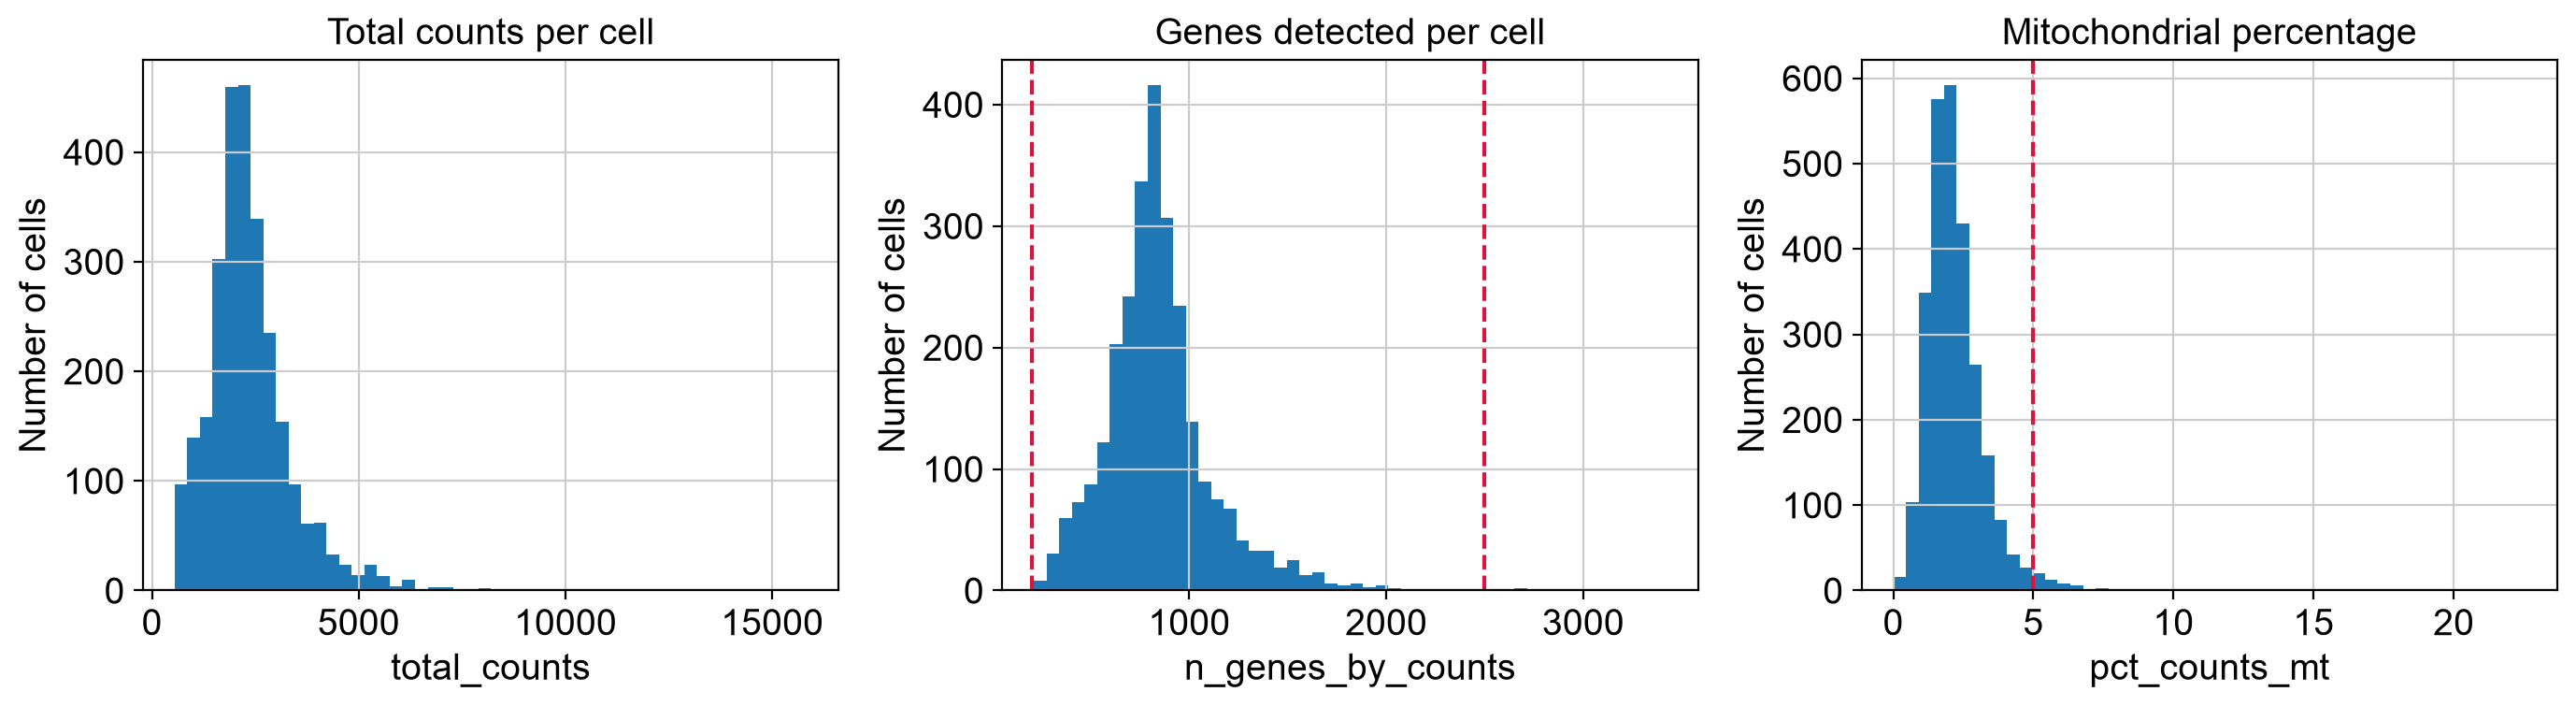

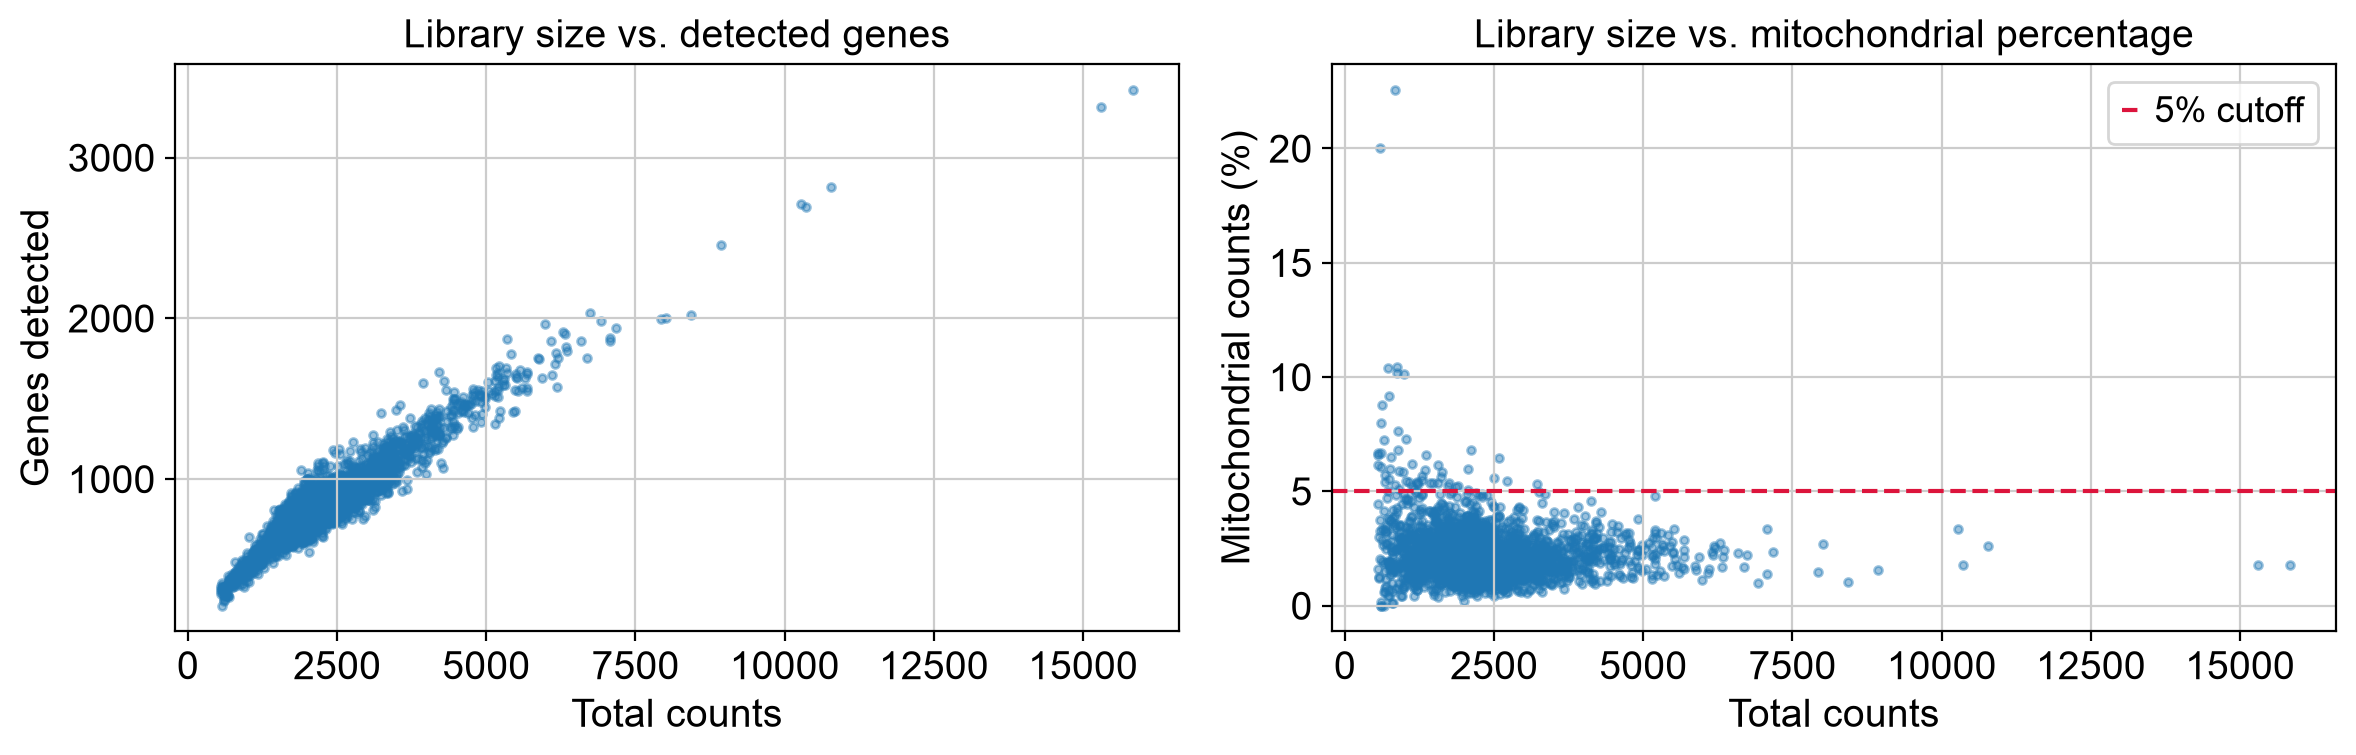

In [4]:
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

qc_columns = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
display(adata.obs[qc_columns].describe().T)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, column, title in zip(
    axes,
    qc_columns,
    ["Total counts per cell", "Genes detected per cell", "Mitochondrial percentage"],
):
    axis.hist(adata.obs[column], bins=50)
    axis.set(xlabel=column, ylabel="Number of cells", title=title)
axes[1].axvline(MIN_GENES_PER_CELL, color="crimson", linestyle="--")
axes[1].axvline(MAX_GENES_PER_CELL, color="crimson", linestyle="--")
axes[2].axvline(MAX_MT_PERCENT, color="crimson", linestyle="--")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(adata.obs["total_counts"], adata.obs["n_genes_by_counts"], s=8, alpha=0.45)
axes[0].set(xlabel="Total counts", ylabel="Genes detected", title="Library size vs. detected genes")
axes[1].scatter(adata.obs["total_counts"], adata.obs["pct_counts_mt"], s=8, alpha=0.45)
axes[1].axhline(MAX_MT_PERCENT, color="crimson", linestyle="--", label=f"{MAX_MT_PERCENT:g}% cutoff")
axes[1].set(xlabel="Total counts", ylabel="Mitochondrial counts (%)", title="Library size vs. mitochondrial percentage")
axes[1].legend()
plt.tight_layout()
plt.show()

## Apply QC filters

Each cell receives explicit pass/fail flags before filtering. The summary reports how many cells fail each rule; cells can fail more than one rule. Genes are filtered only after cell QC.

In [5]:
adata.obs["pass_min_genes"] = adata.obs["n_genes_by_counts"] >= MIN_GENES_PER_CELL
adata.obs["pass_max_genes"] = adata.obs["n_genes_by_counts"] < MAX_GENES_PER_CELL
adata.obs["pass_mt"] = adata.obs["pct_counts_mt"] < MAX_MT_PERCENT
adata.obs["pass_qc"] = adata.obs[["pass_min_genes", "pass_max_genes", "pass_mt"]].all(axis=1)

cell_filter_summary = pd.Series({
    "starting cells": adata.n_obs,
    "below minimum genes": int((~adata.obs["pass_min_genes"]).sum()),
    "at/above maximum genes": int((~adata.obs["pass_max_genes"]).sum()),
    "at/above mitochondrial cutoff": int((~adata.obs["pass_mt"]).sum()),
    "cells passing all QC rules": int(adata.obs["pass_qc"].sum()),
}, name="cells")
display(cell_filter_summary.to_frame())

starting_cells, starting_genes = adata.shape
adata = adata[adata.obs["pass_qc"]].copy()
sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)

# Recalculate metrics on the retained matrix so downstream summaries are current.
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

filter_results = pd.DataFrame({
    "before QC": [starting_cells, starting_genes],
    "after QC": [adata.n_obs, adata.n_vars],
    "removed": [starting_cells - adata.n_obs, starting_genes - adata.n_vars],
}, index=["cells", "genes"])
display(filter_results)
display(adata.obs[qc_columns].describe().T)

,cells
starting cells,2700
below minimum genes,0
at/above maximum genes,5
at/above mitochondrial cutoff,57
cells passing all QC rules,2638


,before QC,after QC,removed
cells,2700,2638,62
genes,32738,13656,19082


,count,mean,std,min,25%,50%,75%,max
total_counts,2638.0,2371.025391,990.121094,556.0,1779.250000,2213.000000,2766.000000,8875.000000
n_genes_by_counts,2638.0,848.606899,262.727587,212.0,699.000000,819.000000,954.000000,2413.000000
pct_counts_mt,2638.0,2.116608,0.843120,0.0,1.520267,2.010702,2.591085,4.995375


## Normalize and log-transform expression

Total-count normalization scales every retained cell to the same target total. `log1p` compresses the large expression range while preserving zero values. The original integer counts remain in `adata.layers['counts']`.

In [6]:
sc.pp.normalize_total(adata, target_sum=NORMALIZATION_TARGET)
sc.pp.log1p(adata)

print("Normalized totals target:", f"{NORMALIZATION_TARGET:,}")
print("Transformation:", adata.uns["log1p"])
print("Raw integer counts preserved in adata.layers['counts']:", "counts" in adata.layers)

Normalized totals target: 10,000
Transformation: {'base': None}
Raw integer counts preserved in adata.layers['counts']: True


## Select genes by standard deviation

For every retained gene, the notebook calculates the population standard deviation across all QC-passing cells using the normalized log-expression matrix. Genes are ranked from highest to lowest standard deviation. The top 2,000 are selected deterministically; no random sampling is used.

,gene_ids,expression_mean,expression_std,std_rank,selected_by_std
LYZ,ENSG00000090382,1.846699,1.898124,1,True
S100A9,ENSG00000163220,1.178651,1.821040,2,True
HLA-DRA,ENSG00000204287,1.768808,1.799511,3,True
CST3,ENSG00000101439,1.262091,1.708006,4,True
TYROBP,ENSG00000011600,1.265203,1.670943,5,True
S100A8,ENSG00000143546,0.889559,1.603235,6,True
NKG7,ENSG00000105374,0.897587,1.559639,7,True
LGALS1,ENSG00000100097,1.362101,1.554240,8,True
CD74,ENSG00000019582,2.571851,1.535899,9,True
CCL5,ENSG00000161570,0.924198,1.506987,10,True


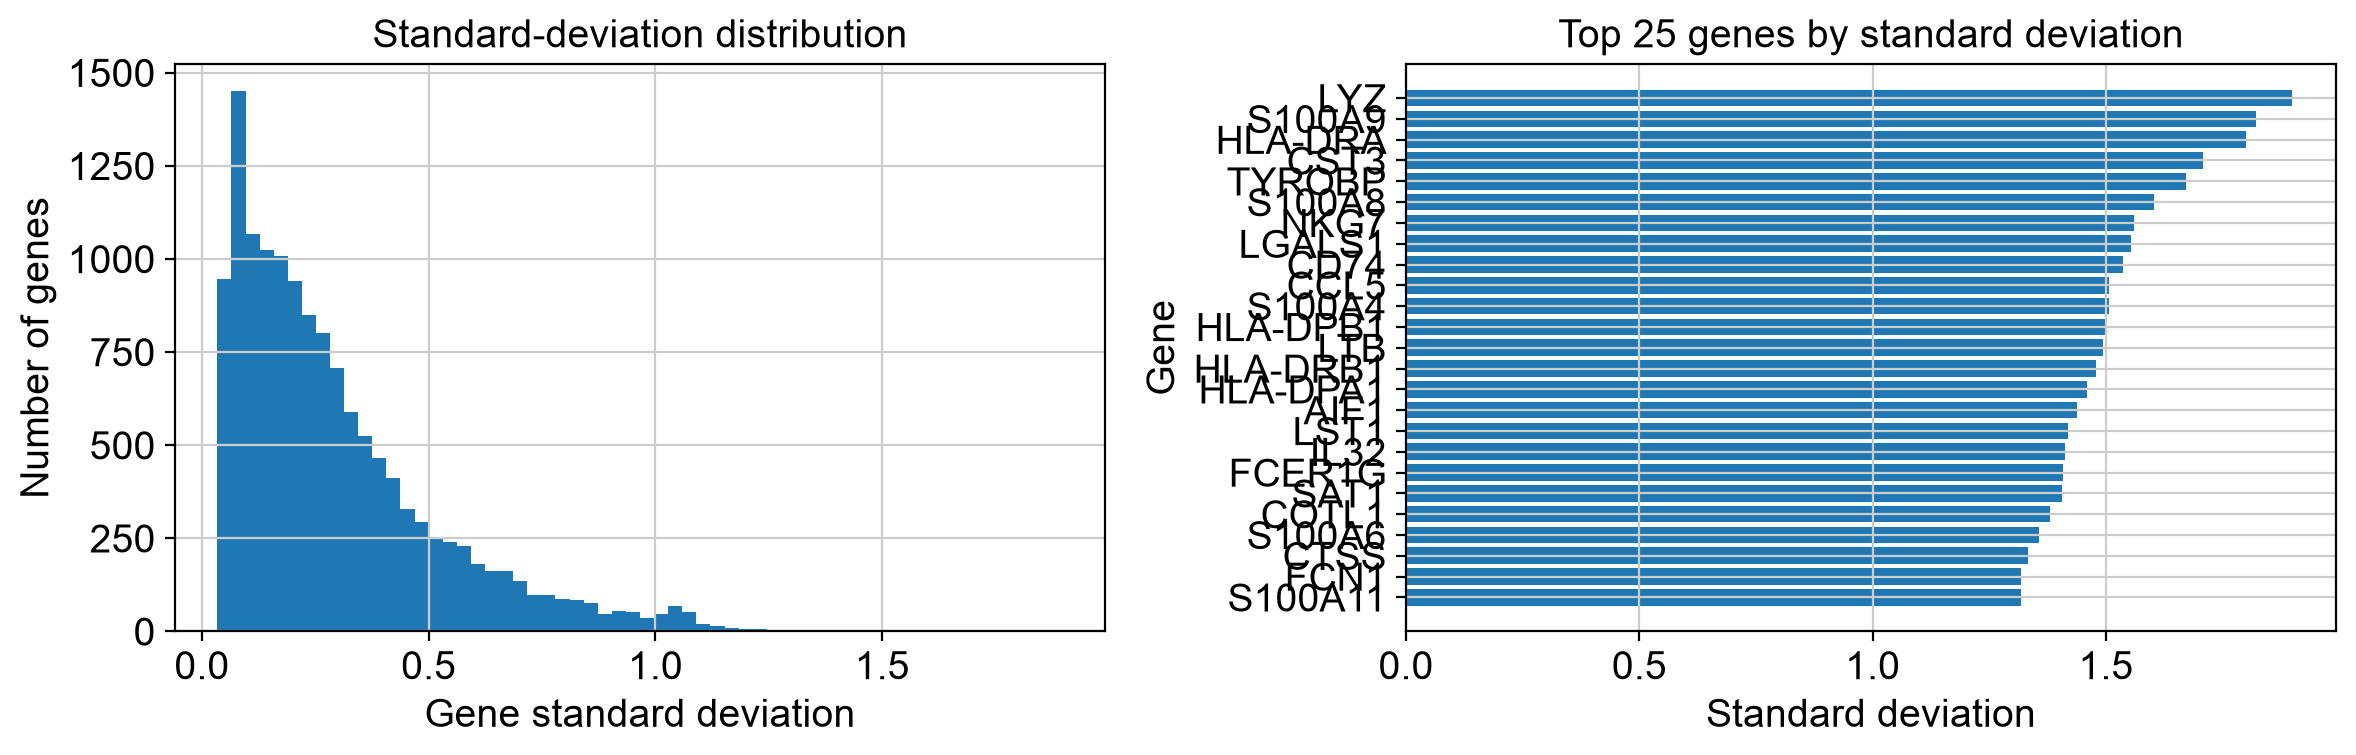

Selected 2,000 of 13,656 retained genes.


In [7]:
expression = adata.X
if sparse.issparse(expression):
    gene_mean = np.asarray(expression.mean(axis=0)).ravel()
    gene_mean_square = np.asarray(expression.power(2).mean(axis=0)).ravel()
else:
    gene_mean = np.asarray(expression).mean(axis=0)
    gene_mean_square = np.square(np.asarray(expression)).mean(axis=0)

gene_variance = np.maximum(gene_mean_square - np.square(gene_mean), 0)
gene_std = np.sqrt(gene_variance)

adata.var["expression_mean"] = gene_mean
adata.var["expression_std"] = gene_std
adata.var["std_rank"] = (
    pd.Series(gene_std, index=adata.var_names)
    .rank(method="first", ascending=False)
    .astype(int)
)
adata.var["selected_by_std"] = adata.var["std_rank"] <= min(N_TOP_SD_GENES, adata.n_vars)

ranked_genes = (
    adata.var[["gene_ids", "expression_mean", "expression_std", "std_rank", "selected_by_std"]]
    .sort_values("std_rank")
)
display(ranked_genes.head(25))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(gene_std, bins=60)
axes[0].set(xlabel="Gene standard deviation", ylabel="Number of genes", title="Standard-deviation distribution")
top_for_plot = ranked_genes.head(25).sort_values("expression_std")
axes[1].barh(top_for_plot.index, top_for_plot["expression_std"])
axes[1].set(xlabel="Standard deviation", ylabel="Gene", title="Top 25 genes by standard deviation")
plt.tight_layout()
plt.show()

print(f"Selected {int(adata.var['selected_by_std'].sum()):,} of {adata.n_vars:,} retained genes.")

## Save the Phase 1 result

The saved object contains only the 2,000 genes selected by standard deviation in its main matrix. Its `.raw` attribute retains normalized log-expression for every QC-passing gene so Phase 3 can perform marker-gene testing without losing genes. Original counts for the selected genes remain in the `counts` layer.

The processed file is intentionally Git-ignored because it can be regenerated by running this notebook.

In [8]:
# Preserve every normalized gene for later marker-gene discovery, then subset
# the main matrix to the deterministic standard-deviation feature set.
adata.raw = adata.copy()
adata_selected = adata[:, adata.var["selected_by_std"]].copy()

output_path = PROCESSED / "pbmc3k_phase1_qc_top2000sd.h5ad"

# AnnData 0.11.4 can write log1p['base']=None using a null encoding that the
# same environment cannot read back. Omitting the key still correctly means
# that Scanpy used the natural logarithm and keeps the file portable.
if isinstance(adata_selected.uns.get("log1p"), dict) and adata_selected.uns["log1p"].get("base") is None:
    del adata_selected.uns["log1p"]["base"]

adata_selected.write_h5ad(output_path, compression="gzip")

phase1_summary = pd.Series({
    "starting cells": starting_cells,
    "QC-passing cells": adata_selected.n_obs,
    "starting genes": starting_genes,
    "genes after detection filter": adata.n_vars,
    "genes selected by standard deviation": adata_selected.n_vars,
    "selection method": "top standard deviation after normalize_total + log1p",
    "output": str(output_path),
}, name="Phase 1 result")
display(phase1_summary.to_frame())
print(f"Saved {output_path.name} ({output_path.stat().st_size / 1024**2:.1f} MB)")

,Phase 1 result
starting cells,2700
QC-passing cells,2638
starting genes,32738
genes after detection filter,13656
genes selected by standard deviation,2000
selection method,top standard deviation after normalize_total +...
output,/Users/Ema/Desktop/cosmos/26-the-backpropagato...


Saved pbmc3k_phase1_qc_top2000sd.h5ad (13.2 MB)


## Phase 1 conclusion

Phase 1 is complete when every cell and gene removal is accounted for, the QC distributions have been reviewed, and the processed file has been saved. Phase 2 should load `pbmc3k_phase1_qc_top2000sd.h5ad` and use its 2,000 selected genes for PCA, neighbor construction, UMAP, and clustering.

For the later supervised classifier, recalculate the standard-deviation ranking using only the training portion of the labeled dataset to prevent information leakage.